## After looking briefly at metrics realised that the criteria have little to no influence on mesh quality
 - Do influence fidelity but I can just choose limits as larger limit will always give more flexibility for tet quality optimisation
 - Size of d0 will influence quality and cell count significanlty so might have to be part of optimisation study
 - Also facet_angle and radius_ratio only apply to sruface mesh and have no influence on the output
    - Thinkn this is partly because input surface is already optimised
 ---
 - below h_bone_max is chosen - and thoughts on it are written in places

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv
from pathlib import Path

## Load data

In [2]:
out_dir = Path('outputs/study1')

df_param = pd.read_csv(out_dir / 'params.csv')
df_runtime = pd.read_csv(out_dir / 'runtimes.csv')
print('Max runtime:', f'{df_runtime['runtime'].max():.2f} s')

Max runtime: 26.98 s


#### Combine study Metrics

In [18]:
prefix = ['study1a', 'study1b', 'study1c']
df_bone, df_cart, df_qual = [], [], []
for p in prefix:
    df_bone.append(pd.read_csv(out_dir / f'{p}-boneMetrics.csv'))
    df_cart.append(pd.read_csv(out_dir / f'{p}-cartMetrics.csv'))
    df_qual.append(pd.read_csv(out_dir / f'{p}-qualMetrics.csv'))
df_bone = pd.concat(df_bone).copy()
df_cart = pd.concat(df_cart).copy()
df_qual = pd.concat(df_qual).copy()
df_qual['total_tets'] = df_qual['bone_n_cells'] + df_qual['cart_n_cells']

In [33]:
df_param

,sub,bone,run_id,h_bone_max,d0,fd_cart_near,fd_cart_far,fd_bone,facet_angle,cell_radius_edge_ratio
0,14548R,tpm,0a,0.5,2,0.02,0.01,0.2,7.5,3
1,14548R,tpm,1a,0.5,2,0.02,0.01,0.2,7.5,6
2,14548R,tpm,2a,0.5,2,0.02,0.01,0.2,7.5,12
3,14548R,tpm,3a,0.5,2,0.02,0.01,0.2,15.0,3
4,14548R,tpm,4a,0.5,2,0.02,0.01,0.2,15.0,6
...,...,...,...,...,...,...,...,...,...,...
2182,14548R,tpm,724c,2.0,8,0.08,0.04,0.8,15.0,6
2183,14548R,tpm,725c,2.0,8,0.08,0.04,0.8,15.0,12
2184,14548R,tpm,726c,2.0,8,0.08,0.04,0.8,30.0,3
2185,14548R,tpm,727c,2.0,8,0.08,0.04,0.8,30.0,6


## Select metrics

In [34]:
d_metric = 'max'

metrics = [

    # fidelity (keep high)
    'bone_orig_rmsdi',
    f'bone_orig_di_{d_metric}',
    'cart_orig_rmsdi',
    f'cart_orig_di_{d_metric}',

    # quality (keep high)
    'cart_inner_min_angle_worst',
    'cart_inner_scaled_jacobian_worst',

    # cell count (keep low)
    'total_tets'

]


bone = df_bone[
    ['sub', 'bone', 'run_id', 'orig_rmsdi', f'orig_di_{d_metric}']
].rename(columns={
    'orig_rmsdi': 'bone_orig_rmsdi',
    f'orig_di_{d_metric}': f'bone_orig_di_{d_metric}'
})

cart = df_cart[
    ['sub', 'bone', 'run_id', 'orig_rmsdi', f'orig_di_{d_metric}']
].rename(columns={
    'orig_rmsdi': 'cart_orig_rmsdi',
    f'orig_di_{d_metric}': f'cart_orig_di_{d_metric}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        'cart_inner_min_angle_worst',
        'cart_inner_scaled_jacobian_worst',
        'total_tets'
    ]
]

df = (
    bone
    .merge(cart, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)

#### Check distributions

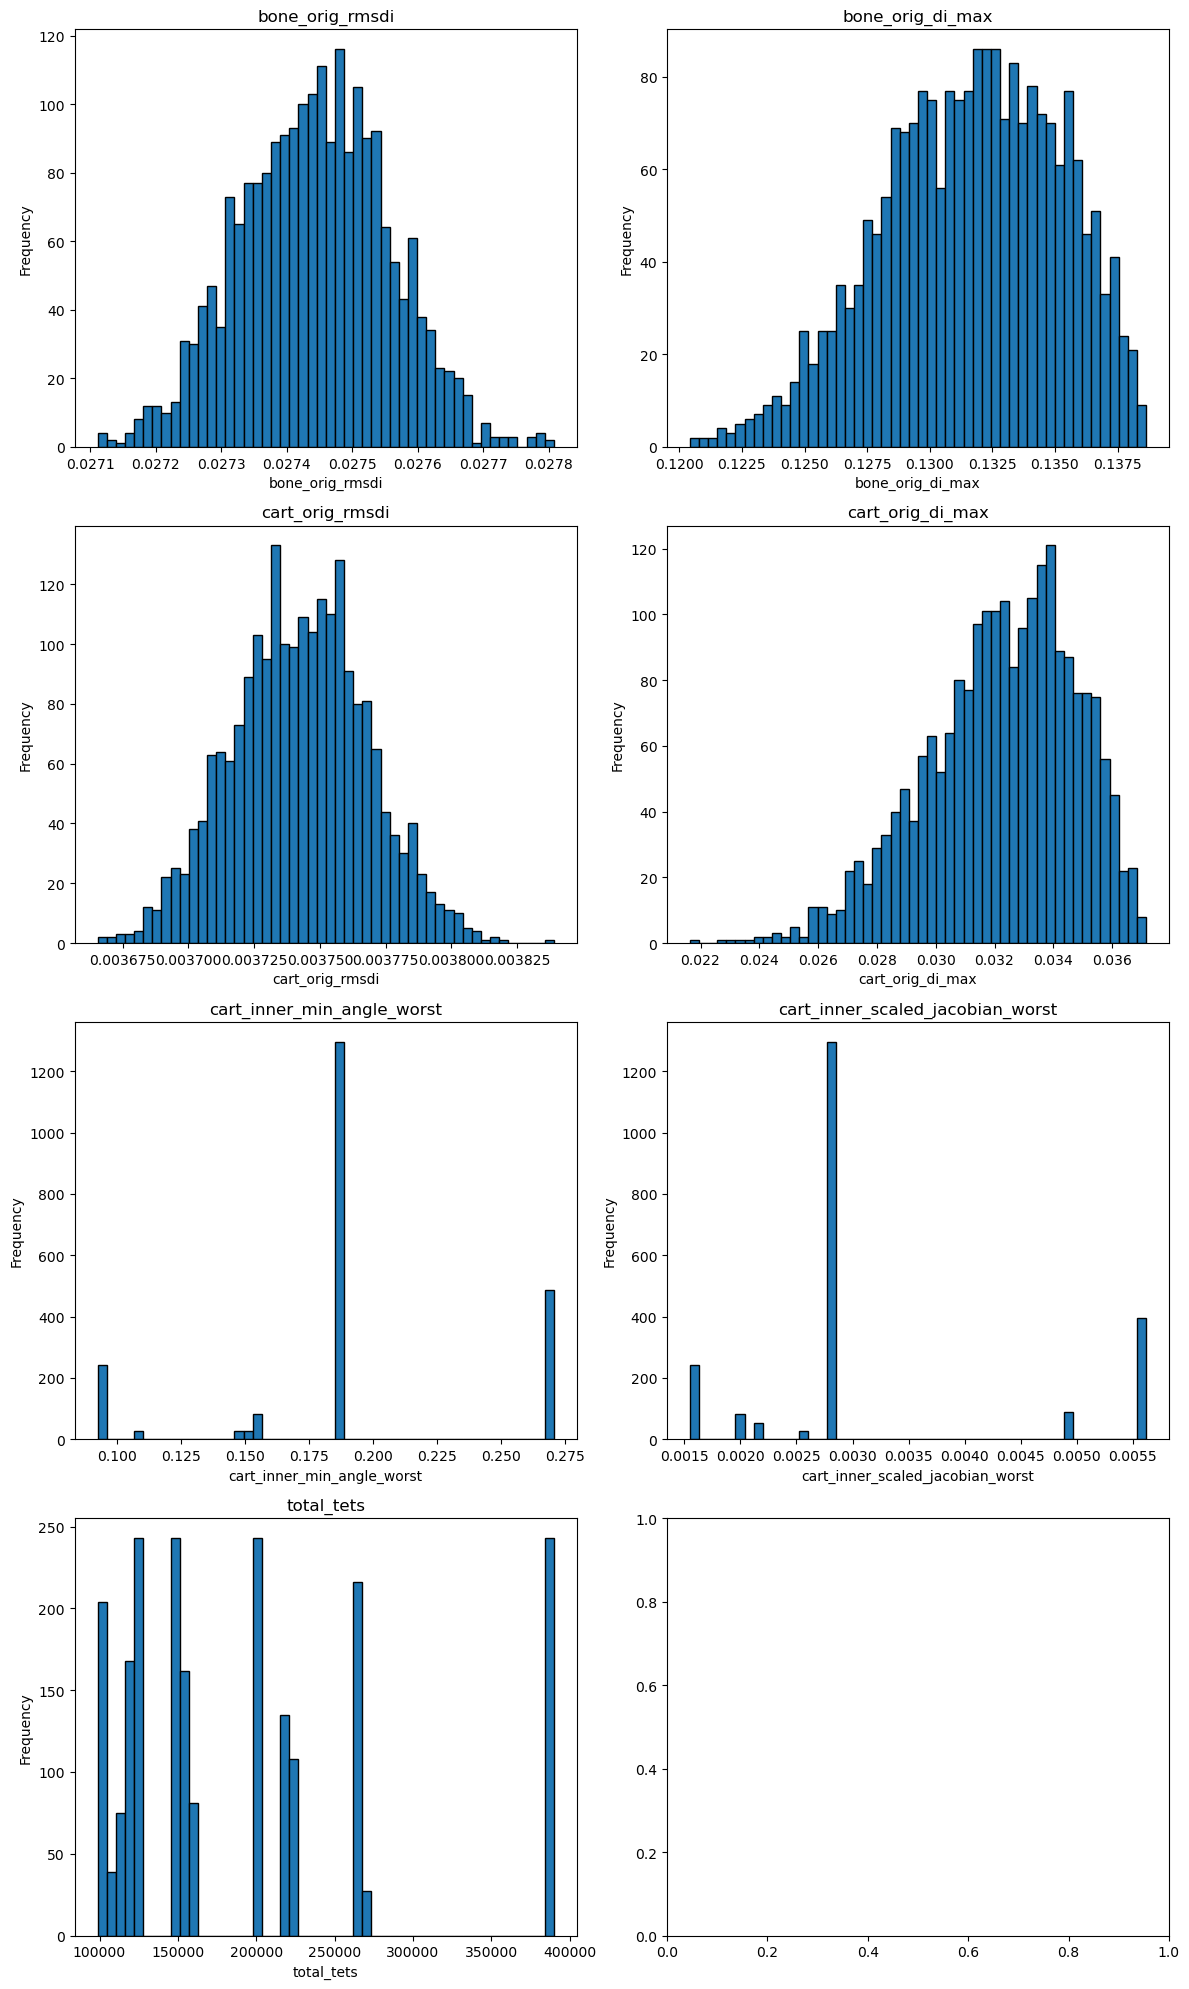

In [35]:
fig, ax = plt.subplots(4, 2, figsize=(12, 20))
ax = ax.flatten()

for i, metric in enumerate(metrics):
    values = df[metric]
    # Histogram
    ax[i].hist(values, bins=50, edgecolor='black')
    ax[i].set_title(metric)
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Frequency')


plt.tight_layout()
plt.show()

### Run with fd_bone: [0.25, 0.50, 1.0] ; "h_bone_max": 5.0

In [69]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/fd_test/test1/params/full_params-3.json

SUBJECT: 14548R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.547s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 1.507s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 7.295s - ok
			RUN ID: -0-0-1
			Runtime: 7.486s - ok
			RUN ID: -0-0-2
			Runtime: 7.570s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [155]:
root_dir = Path('outputs/fd_test/test1') # path to parent of output_root in set_parameters


sub = '14548R'
bones = 'tpm-mc1'

mesh3d_025 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-0.vtu').extract_cells_by_type(5)
mesh3d_05 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-1.vtu').extract_cells_by_type(5)
mesh3d_10 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-2.vtu').extract_cells_by_type(5)

# Determine max bone cell size
Find a max cell size that doesn't require an unreasonable facet distance


 - measure the gdist of bone points from boudnary, get bone points far enough away that arn't influenced by refined cartilage mesh (also don't care about cells that are certain to be in the final taper region)
     - look at cell sizes in this 
     
 - Both 0.25 and 1.0 have same cell size ranges when max size = 5.0 - ranges are too big to be sure of smooth size transitions between them
 - FD of 0.25 requires too much refinement in certain areas
 - FD of 1.0 results in resonable fidelity everywhere
 - Therefore, set FD to 1.0 and max cell size to 1.0 -> 1.5 ? 
    - This isn't too much larger than the small cell sizes needed for curved region, and prevents extreme cell size jumps between regions.
    - checking how they look below

---
- This also shows that once d0 hits ~8->10 mm that covers the whole distance

In [173]:
import gdist
from scipy.spatial.distance import cdist

mesh = mesh3d_10
bone_surf = mesh.extract_cells(mesh['region_id']==-1).extract_surface(algorithm=None)
boundary_ids = np.arange(bone_surf.n_points)[np.where(bone_surf.point_data['medit:ref']==-1)]

geo_dists = gdist.compute_gdist(
    bone_surf.points.astype(np.float64),
    bone_surf.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
    source_indices=boundary_ids.astype(np.int32), 
) 
dists = cdist(bone_surf.points, bone_surf.points[boundary_ids]).min(axis=1)

mask = geo_dists >= 3.5
mask = dists >= 8

base = bone_surf.extract_points(mask, adjacent_cells=False).extract_surface(algorithm=None)
A = base.compute_cell_sizes(length=False, volume=False)["Area"]

# circumradius
R = np.sqrt(4 * A / (3 * np.sqrt(3))) 
print(f'Min size = {R.min():.4f}')
print(f'Max size = {R.max():.4f}')

Min size = 1.4296
Max size = 2.0831


In [174]:
p = np.array([75.5, 67.2, 84.0])

pl = pv.Plotter()
pl.add_mesh(base, show_edges=True, color='green')
pl.add_points(p, point_size=20, render_points_as_spheres=True)
pl.camera_position = pv.CameraPosition(position=(80.04865720184003, 47.95326722496728, 93.54402720387564),
               focal_point=(75.04026004178999, 73.30120446284118, 83.84261594582057),
               viewup=(0.6375877382829819, 0.3820194923524485, 0.668986534583447))
pl.add_axes()
print(R[base.find_closest_cell(p)])
pl.show()

1.5888527199735976


Widget(value='<iframe src="http://localhost:62186/index.html?ui=P_0x3c2619220_78&reconnect=auto" class="pyvist…

### Run again with "h_bone_max": [0.8, 1.0, 1.25, 1.5] ; fd_bone: 1.0

In [150]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/fd_test/test2/params/full_params-2.json

SUBJECT: 14548R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.511s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 1.645s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 7.845s - ok
			RUN ID: -0-0-1
			Runtime: 7.386s - ok
			RUN ID: -0-0-2
			Runtime: 7.435s - ok
			RUN ID: -0-0-3
			Runtime: 7.353s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [151]:
root_dir = Path('outputs/fd_test/test2') # path to parent of output_root in set_parameters


sub = '14548R'
bones = 'tpm-mc1'

mesh3d_08 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-0.vtu').extract_cells_by_type(10)
mesh3d_10 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-1.vtu').extract_cells_by_type(10)
mesh3d_125 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-2.vtu').extract_cells_by_type(10)
mesh3d_15 = pv.read(root_dir / f'meshes/{sub}/{bones}/3Dmesh/mesh-0-0-3.vtu').extract_cells_by_type(10)

print(mesh3d_08.n_cells)
print(mesh3d_10.n_cells)
print(mesh3d_125.n_cells)
print(mesh3d_15.n_cells)

116743
111385
108982
107832


#### cell count differences are close to negligable so might aswell user smaller limit for better transitions
 - Let's use 1.0
    - low cell count and round number and no big size jumps from curved to flat

In [152]:
p = np.array([75.5, 67.2, 84.0])

pl = pv.Plotter()
pl.add_mesh(mesh3d_08, show_edges=True)
pl.add_points(p, point_size=20, render_points_as_spheres=True)
pl.camera_position = pv.CameraPosition(position=(80.04865720184003, 47.95326722496728, 93.54402720387564),
               focal_point=(75.04026004178999, 73.30120446284118, 83.84261594582057),
               viewup=(0.6375877382829819, 0.3820194923524485, 0.668986534583447))
pl.add_axes()
print(R[base.find_closest_cell(p)])
pl.show()

0.8062851776589043


Widget(value='<iframe src="http://localhost:62186/index.html?ui=P_0x3a1ebca70_68&reconnect=auto" class="pyvist…

In [153]:
p = np.array([75.5, 67.2, 84.0])

pl = pv.Plotter()
pl.add_mesh(mesh3d_10, show_edges=True)
pl.add_points(p, point_size=20, render_points_as_spheres=True)
pl.camera_position = pv.CameraPosition(position=(80.04865720184003, 47.95326722496728, 93.54402720387564),
               focal_point=(75.04026004178999, 73.30120446284118, 83.84261594582057),
               viewup=(0.6375877382829819, 0.3820194923524485, 0.668986534583447))
pl.add_axes()
print(R[base.find_closest_cell(p)])
pl.show()

0.8062851776589043


Widget(value='<iframe src="http://localhost:62186/index.html?ui=P_0x39fca5fa0_69&reconnect=auto" class="pyvist…

# Rank them
 - for fidelity and quality, set value above which is ideal gets 1 point, the points decrease linealry between ideal and worst acceptable then 0 below that
 - maybe just rank element count normally
    - could even ignore element count at first just see whats best

In [ ]:
finalise facet distance and size choices
 - why 0.05?d - maybe don't ever have to mention facet distance in write up 
     - just ensure that final mesh is within chosen distance
     - still choose that value for this aswell but base it purely on that 
        - look back at what has been allowed in taper-box and remesh-box

plan mesh optimisation study

use these metrics as mock ouputs to figure out how to evaluate best
